In [5]:
from google.colab import drive
import os

# 1. Connect Colab to your Google Drive
drive.mount('/content/drive')

# 2. Unzip your dataset directly into Colab's fast memory
# IMPORTANT: Change the path below if you put the zip inside a specific Drive folder!
!unzip -q "/content/drive/MyDrive/masks and enchanched images.zip" -d "/content/dataset"

print("Dataset successfully loaded into Colab!")

Mounted at /content/drive
Dataset successfully loaded into Colab!


In [6]:
!pip install segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.8 MB/s eta 0:00:00


In [10]:
import os
import cv2
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

class FoliculometryDataset(Dataset):
    def __init__(self, images_dir, masks_dir):
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        # Get a list of all image filenames
        self.images = sorted(os.listdir(images_dir))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        # 1. Get the filenames
        img_name = self.images[idx]
        # Assuming your mask names are like "image1_mask.png"
        mask_name = img_name.replace('.jpg', '_mask.png') # Adjust extension if needed!

        # 2. Load the images
        img_path = os.path.join(self.images_dir, img_name)
        mask_path = os.path.join(self.masks_dir, mask_name)

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        # 3. Resize them so the AI gets a consistent 256x256 square
        image = cv2.resize(image, (256, 256))
        mask = cv2.resize(mask, (256, 256))

        # 4. Normalize and convert to PyTorch Tensors
        image = image / 255.0
        mask = mask / 255.0

        # PyTorch expects channels first: (Channels, Height, Width)
        image = np.transpose(image, (2, 0, 1))

        image_tensor = torch.tensor(image, dtype=torch.float32)
        # Mask needs a channel dimension added: (1, Height, Width)
        mask_tensor = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)

        return image_tensor, mask_tensor

# Test to make sure it works!
dataset = FoliculometryDataset('/content/dataset/enhanced_images', '/content/dataset/masks')
print(f"Total images loaded: {len(dataset)}")


Total images loaded: 27


In [11]:
import segmentation_models_pytorch as smp
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm # This gives us a cool loading bar!

# 1. Setup the Hardware & Data Loaders
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device} (If this says 'cpu', go to Runtime -> Change Runtime Type and select T4 GPU!)")

# We process images in small batches of 4 so we don't crash the GPU memory
train_loader = DataLoader(dataset, batch_size=4, shuffle=True)

# 2. Build the AFCA Brain (U-Net + ResNet34)
# We use ResNet34 because it's pre-trained on millions of images. It already knows how to see shapes and edges!
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,                  # 3 channels for RGB images
    classes=1,                      # 1 class because we only want to find "follicles"
).to(device)

# 3. The "Teacher" Tools
# BCEWithLogitsLoss is perfect for binary classification (Black vs. White pixels)
criterion = nn.BCEWithLogitsLoss()
# Adam is the optimizer that adjusts the math weights to make the model smarter
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 4. The Training Loop!
epochs = 15 # We will run through your entire dataset 15 times
print("Starting AFCA Training Phase...\n")

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    # Loop through our batches of 4 images
    for images, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
        images = images.to(device)
        masks = masks.to(device)

        # Step A: Clear the old math
        optimizer.zero_grad()

        # Step B: Make a prediction
        outputs = model(images)

        # Step C: Calculate how wrong the prediction was compared to your hand-drawn masks
        loss = criterion(outputs, masks)

        # Step D: Update the AI's brain (Backpropagation)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # Print the average loss for this epoch
    avg_loss = running_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{epochs}] Completed - Average Loss: {avg_loss:.4f}\n")

print("Training Complete! The AFCA model is now ready.")

# 5. Save the brain!
torch.save(model.state_dict(), "afca_unet_model.pth")
print("Model saved successfully as 'afca_unet_model.pth'")

Training on: cuda (If this says 'cpu', go to Runtime -> Change Runtime Type and select T4 GPU!)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Starting AFCA Training Phase...



...

Epoch [13/15] Completed - Average Loss: 0.0772



Epoch 14/15: 100%|██████████| 7/7 [00:00<00:00, 14.67it/s]


Epoch [14/15] Completed - Average Loss: 0.0749



Epoch 15/15: 100%|██████████| 7/7 [00:00<00:00, 14.82it/s]


Epoch [15/15] Completed - Average Loss: 0.0714

Training Complete! The AFCA model is now ready.
Model saved successfully as 'afca_unet_model.pth'


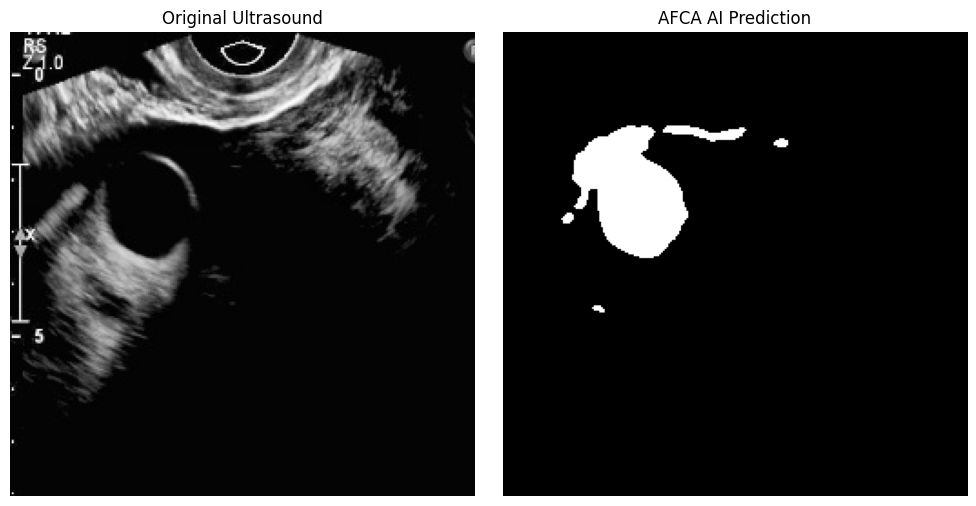

In [12]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import random
import  segmentation_models_pytorch as smp

# 1. Setup Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Rebuild the Brain Structure and Load Your Trained Weights
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights=None,           # We don't need generic weights anymore...
    in_channels=3,
    classes=1,
).to(device)

# Load the custom AFCA brain you just trained!
model.load_state_dict(torch.load("afca_unet_model.pth", map_location=device))
model.eval() # Set to evaluation mode (turns off training updates)

# 3. Pick a random ultrasound image from your folder
image_folder = '/content/dataset/enhanced_images'
random_image_name = random.choice(os.listdir(image_folder))
image_path = os.path.join(image_folder, random_image_name)

# 4. Prepare the image for the AI (same math as before)
raw_image = cv2.imread(image_path)
raw_image = cv2.cvtColor(raw_image, cv2.COLOR_BGR2RGB)
resized_image = cv2.resize(raw_image, (256, 256))

# Convert to PyTorch Tensor format
image_tensor = resized_image / 255.0
image_tensor = np.transpose(image_tensor, (2, 0, 1))
image_tensor = torch.tensor(image_tensor, dtype=torch.float32).unsqueeze(0).to(device)

# 5. The Magic AI Prediction!
with torch.no_grad(): # Don't calculate gradients, just predict
    prediction = model(image_tensor)

    # We used BCEWithLogitsLoss, so we need a Sigmoid to squash numbers between 0 and 1
    prediction = torch.sigmoid(prediction)

    # Any pixel above 0.5 confidence is a follicle (White), otherwise background (Black)
    predicted_mask = (prediction.squeeze().cpu().numpy() > 0.5).astype(np.uint8)

# 6. Visualize the Results
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Show Original
axes[0].imshow(resized_image)
axes[0].set_title("Original Ultrasound")
axes[0].axis('off')

# Show AI Prediction
axes[1].imshow(predicted_mask, cmap='gray')
axes[1].set_title("AFCA AI Prediction")
axes[1].axis('off')

plt.tight_layout()
plt.show()

AFCA AI detected 5 distinct fluid pockets. Calculating biometry...



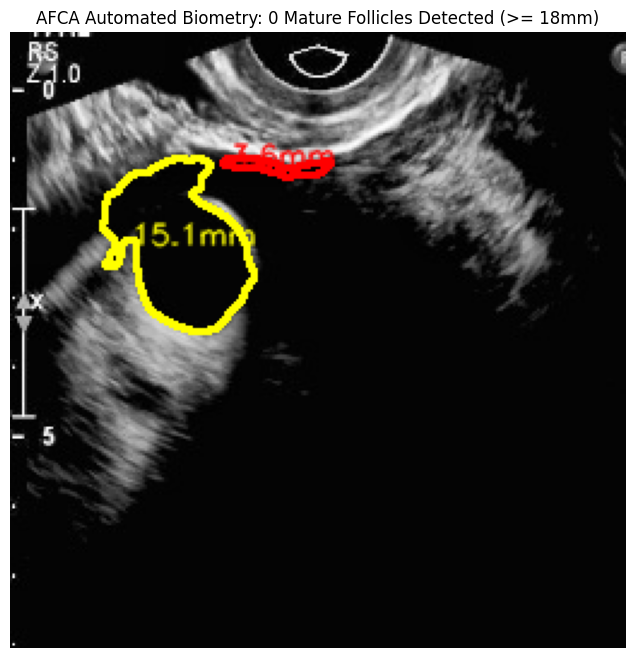

In [13]:
import cv2
import math
import numpy as np
import matplotlib.pyplot as plt

# 1. The Hackathon Calibration (Pixel to mm)
PIXEL_TO_MM = 0.25

# 2. Make a copy of the original image so we can draw on it
# (This uses the 'resized_image' and 'predicted_mask' from the cell above)
output_image = resized_image.copy()

# 3. Find the distinct blobs (contours) in the AI's mask
# cv2.RETR_EXTERNAL ensures we only trace the outer edge of the fluid
contours, _ = cv2.findContours(predicted_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

print(f"AFCA AI detected {len(contours)} distinct fluid pockets. Calculating biometry...\n")

mature_count = 0

# 4. Measure each follicle one by one
for contour in contours:
    # Calculate the area of the blob in pixels
    area_px = cv2.contourArea(contour)

    # Ignore microscopic AI noise (anything under 50 pixels)
    if area_px < 50:
        continue

    # Math: Area = pi * (radius)^2 -> Diameter = 2 * sqrt(Area / pi)
    radius_px = math.sqrt(area_px / math.pi)
    diameter_px = radius_px * 2

    # Convert pixels to actual millimeters
    diameter_mm = diameter_px * PIXEL_TO_MM

    # 5. Clinical Decision Logic (Color Coding)
    if diameter_mm >= 18.0:
        # Ready for IVF Trigger! Draw in GREEN
        color = (0, 255, 0) # RGB Green
        mature_count += 1
    elif diameter_mm >= 10.0:
        # Growing nicely. Draw in YELLOW
        color = (255, 255, 0)
    else:
        # Baseline/Small. Draw in RED
        color = (255, 0, 0)

    # 6. Draw the outline and the measurement on the image
    cv2.drawContours(output_image, [contour], -1, color, 2)

    # Find the mathematical center of the blob to place the text
    M = cv2.moments(contour)
    if M["m00"] != 0:
        cX = int(M["m10"] / M["m00"])
        cY = int(M["m01"] / M["m00"])

        # Write the size in mm right inside/next to the follicle
        cv2.putText(output_image, f"{diameter_mm:.1f}mm", (cX - 20, cY),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1, cv2.LINE_AA)

# 7. Show the final Clinical Report!
plt.figure(figsize=(8, 8))
plt.imshow(output_image)
plt.title(f"AFCA Automated Biometry: {mature_count} Mature Follicles Detected (>= 18mm)")
plt.axis('off')
plt.show()